## Frozen Lake

![Frozen Lake](https://gymnasium.farama.org/_images/frozen_lake.gif)


## Creating the environment

Frozen Lake is one of the simplest environment in which to test RL algorithms. It is a discrete environment, consisting of a 4x4 grid of possible positions for the agent to occupy (position = current_row * ncols + current_col). The agent itself can move in the 4 directions, going down/up (1/3) or left/right (0/2).

The agent starts in the first cell (the 0th cell) and it's objective is to reach the opposite cell (the 15th cell) without visiting certain positions which represent holes in the ice. Upon reaching the goal, the agent's reward equals one, otherwise zero.

Each episode ends if either the agent falls into a hole or reaches the goal. Another possibility is for the episode to reach the truncation limit, which is set by default to 100. There is also an 8x8 variant with a 200 truncation limit.

In [ ]:
import numpy as np
import gymnasium as gym
import random
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
env = gym.make("FrozenLake-v1", is_slippery=False)

Since the Frozen Lake environment is a 4x4 grid, we have 16 possible states comprising the holes in the lake and the target position. The agent is allowed to move in the 4 cardinal directions, therefore the action space is 4-dimensional.

Since the Q-table is used to represent the estimated Q-value for each possible combinations of state (the rows) and action (the columns), it's dimension is 16x4 = 64.

In [ ]:
state_size = env.observation_space.n
print(state_size)

16


In [ ]:
action_size = env.action_space.n
print(action_size)

4


We can initialize the array values to zero. This is just one of the possibile choices. For example one could use random numbers from a standard normal distribution or go for optimistic initial values which could improve initial exploration.

In [ ]:
qtable = np.zeros((16,4))

#Reinforcement Learning through Q-Learning (T1, T2)

##The Bellman Equation and the Temporal Difference Error
Q-Learning is one of the fundamental approaches to Reinforcement Learning. The Q refers to the qvalue function, which is used to measure the quality of an action as the expected reward from performing it. The algorithm is based on the Bellman Equation, which finds applications in Control Theory and Economics as well:

$$Q(S_t,A_t) = Q(S_t,A_t) + \alpha\left(R_{t+1} + \gamma \max_{a'} Q(S_{t+1},a') - Q(S_t,A_t) \right)$$

This equation iteratively updates the qvalues using the information gathered by the agent's exploration of the environment. It takes into consideration the reward $R_{t+1}$ the agent obtains when performing a certain action $A_t$ from a certain state $S_t$ together with the qvalue of the actions $A_{t+1}$ the agent has available in $S_{t+1}$. It does this in the "Temporal Difference" error term, by comparing what we expected based on previous knowledge to the reward obtained and the next step expected reward: $R_{t+1} + γmax_{a'} (Q(S_{t+1}, a') - Q(S_t, A_t)$. The process is mediated by two parameters, the learning rate $α$ and the discount factor $γ$. The learning rate specifies how big of a step to take each time, while the discount factor suggests the model to me more myopic, that is to prioritize short-term rewards, or to be more farsighted and prioritize long-term gains.

We implement it below by updating the Qtable entry by entry.



##The parameters and the epsilon-decay strategy

Even in such a simple RL application we have many parameters. Besides the already cited $α$ and $γ$, there is the $\epsilon$, which is used in the policy. The policy is the strategy we follow to choose actions. $ϵ$ gives the probability of selecting the action in a non-greedy way, which determines how much exploration we do instead of exploiting what we already know about the expected returns. We use a dynamic approach in which we select a starting epsilon value and then allow it to decay exponentially following the decay_rate parameter, until the value reaches a minimum. This dynamic value allows for a stronger exploration of the action space and their rewards in the beginning and instead, later in the training, a focus on exploiting what we have learned.

Other parameters include the number of total episodes and an upper bound on the number of steps for each episode. In the successive section, we use a rather simple grid search to find a combination which works well.

In [ ]:
epsilon = 0.3
epsilon_0 = epsilon
min_epsilon = 0.01
decay_rate = 0.001

gamma = 0.5
alfa = 0.5

total_episodes = 1200
max_steps = 100

##The actual loop implementation

The training often needs to be repeated a few times as the algorithm isn't always able to properly leave, leaving the qtable at zero. This is likely a problem with the initial exploration. I haven't been able to find a combination of parameters that avoids this problem completely.

In [ ]:
rewards = []

for episode in range(total_episodes):
  state, _ = env.reset()
  step = 0
  done = False
  total_rewards = 0


  for step in range(max_steps):
    uniform_sample = np.random.rand()

    if uniform_sample > epsilon:
      action = np.argmax(qtable[state,:])
    else:
      action = env.action_space.sample()


    new_state, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated

    qtable[state, action] = qtable[state, action] + alfa*(reward + gamma*(np.max(qtable[new_state,:]))*(1-done) - qtable[state, action])

    total_rewards += reward
    state = new_state

    if done:
      break

  epsilon = min_epsilon + (epsilon_0 - min_epsilon)*np.exp(-decay_rate*episode)
  rewards.append(total_rewards)

env.close()
print(qtable)



[[1.56250000e-02 3.12500000e-02 7.81250000e-03 1.56250000e-02]
 [1.56250000e-02 0.00000000e+00 3.33111511e-03 1.81931785e-04]
 [7.64656338e-03 0.00000000e+00 0.00000000e+00 1.78718838e-03]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [3.12500000e-02 6.25000000e-02 0.00000000e+00 1.56250000e-02]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 2.50000000e-01 0.00000000e+00 6.52583574e-04]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [6.25000000e-02 0.00000000e+00 1.25000000e-01 3.12500000e-02]
 [6.25000000e-02 2.50000000e-01 2.50000000e-01 0.00000000e+00]
 [1.25000000e-01 5.00000000e-01 0.00000000e+00 1.25000000e-01]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 2.49199651e-01 5.00000000e-01 1.23433091e-01]
 [2.50000000e-01 5.00000000e-01 1.00000000e+00 2.50000000e-01]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.000000

#Analysis of the non-slippery results (T3)

To better understand the learning progress, we can plot the moving average of the rewards. This helps in smoothing out the individual episode rewards (which are either 0 or 1) and help identify any trend in the agent's performance.

The moving average has strong fluctuations, but there is a clear upward trend which often ends up in 80%+ success rate.

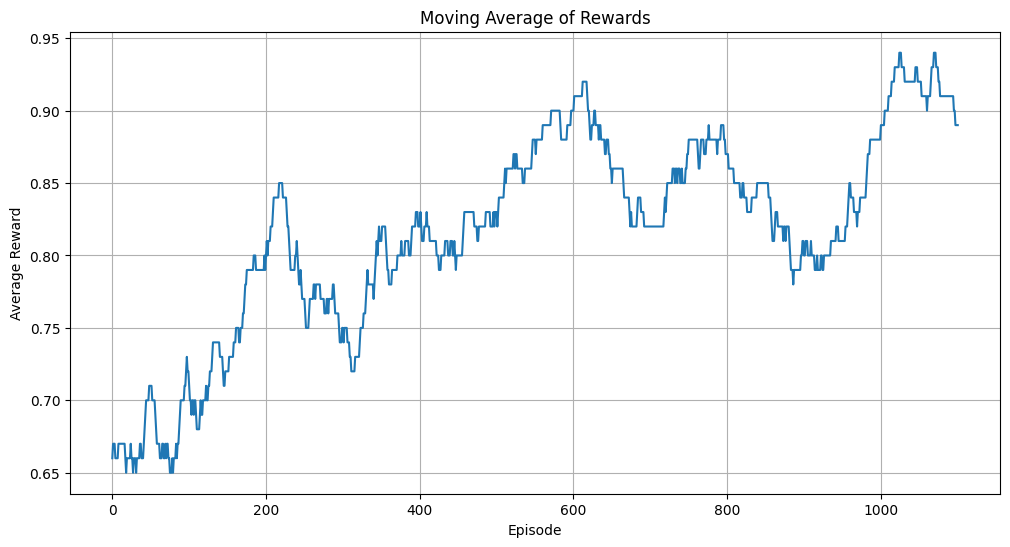

In [ ]:
window_size = 100
moving_avg_rewards = np.convolve(rewards, np.ones(window_size)/window_size, mode='valid')

plt.figure(figsize=(12, 6))
plt.plot(moving_avg_rewards)
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("Moving Average of Rewards")
plt.grid(True)
plt.show()

The action with the highest value for a given state is the one the algorithm selects with probability $1-ϵ$. For the Frozen Lake Environment, the reward is always zero except for the transition to the goal cell, which gives a reward of 1. This means that, even with Q-learning which takes into consideration future possible rewards, most values in the qtable are very small in magnitude. This isn't a problem as their relative magnitude is really what matters.

We can build a heatmap with the same dimensions as the grid to see the highest qvalue for each. The highest qvalues are of course close to the goal cell, with the 14th cell having an expected reward of 1 by going right. It's interesting to see how even in such a simple setting the policy does change often, with some obvious routes sometimes avoided in favor of less optimal ones.

In [ ]:
print(np.max(qtable, axis=1))

[0.03125    0.015625   0.00764656 0.         0.0625     0.
 0.25       0.         0.125      0.25       0.5        0.
 0.         0.5        1.         0.        ]


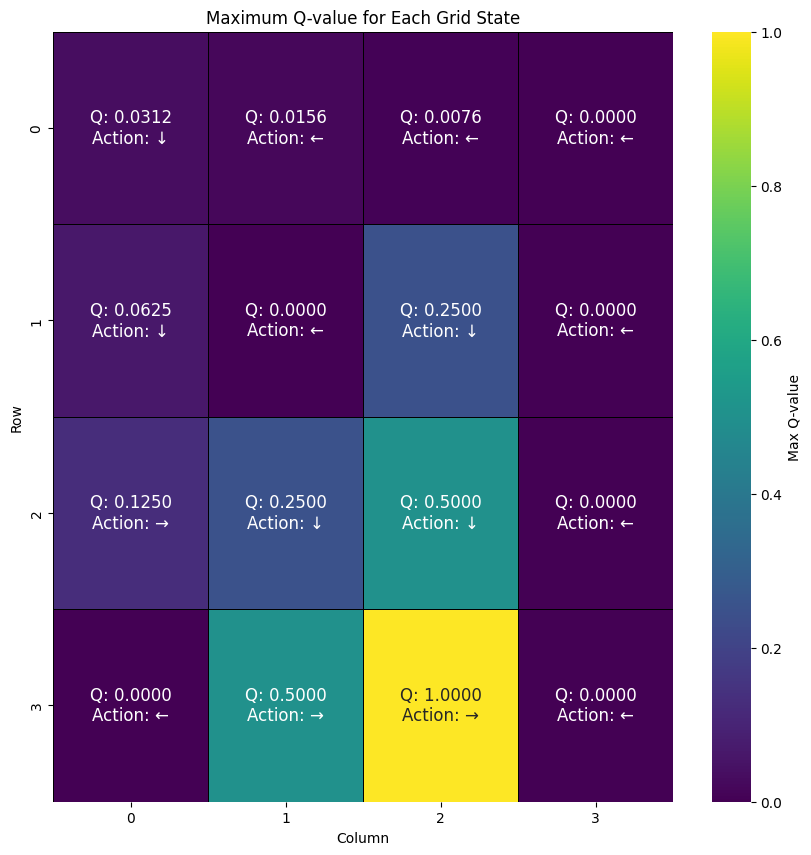

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
max_q_values = np.max(qtable, axis=1)
optimal_actions = np.argmax(qtable, axis=1)

#A map to showcase the action
action_symbols = {0: '←', 1: '↓', 2: '→', 3: '↑'}
optimal_actions_symbols = np.array([action_symbols[a] for a in optimal_actions])

annotations = []
for i in range(len(max_q_values)):
    annotations.append(f"Q: {max_q_values[i]:.4f}\nAction: {optimal_actions_symbols[i]}")

max_q_values_grid = max_q_values.reshape(4, 4)
annotations_grid = np.array(annotations).reshape(4, 4)

plt.figure(figsize=(10, 10))
sns.heatmap(max_q_values_grid, annot=annotations_grid, cmap="viridis", fmt="",
            linewidths=.5, linecolor='black',
            cbar_kws={'label': 'Max Q-value'},
            cbar=True,
            annot_kws={"size": 12})
plt.title("Maximum Q-value for Each Grid State")
plt.xlabel("Column")
plt.ylabel("Row")

plt.show()

##Optimizing the Parameters

From previous manual testing, it was evident that the specific parameters selected have a very important effect on the model performances. To explore the parameters space in a more structured way, we can use grid search and define a grid of points, test all the combinations and see which one performs better by considering the average return over the last 100 episodes.

In [ ]:
alfa_values = [0.01, 0.1, 0.3, 0.5, 0.7, 0.9]
gamma_values = [0.1, 0.3, 0.5, 0.7, 0.9]
epsilon_0_values = [0.1, 0.3, 0.5, 0.7, 0.9]
decay_rate_values = [0.0001, 0.0005, 0.001]

print(f"Total number of combinations tested {len(alfa_values)*len(gamma_values)*len(epsilon_0_values)*len(decay_rate_values)}")

Total number of combinations tested 450


For each combination, we re-initialize the Q-table and re-train the Q-learning agent. We keep some of the parameters fixed to make the results more easily comparable and to avoid lenghtening the process unnecessarily. These are the total episodes, the max number of steps and the minimum value of epsilon.


In [ ]:
import itertools #Permette di scrivere semplicemente il loop

best_reward = -np.inf
best_params = {}

#Fixed parameters
total_episodes_grid = 1200
max_steps_grid = 100
min_epsilon_grid = 0.01
window_size_grid = 100

env_grid = gym.make("FrozenLake-v1", is_slippery=False)
state_size_grid = env_grid.observation_space.n
action_size_grid = env_grid.action_space.n

#Iteration through all combinations
for alfa_val, gamma_val, epsilon_0_val, decay_rate_val in itertools.product(alfa_values, gamma_values, epsilon_0_values, decay_rate_values):
    print(f"\nTraining with: alfa={alfa_val}, gamma={gamma_val}, epsilon_0={epsilon_0_val}, decay_rate={decay_rate_val}")

    #Re-initialize Q-table for the current combination
    current_qtable = np.zeros((state_size_grid, action_size_grid))

    epsilon_current = epsilon_0_val
    epsilon_0_current = epsilon_0_val
    decay_rate_current = decay_rate_val
    gamma_current = gamma_val
    alfa_current = alfa_val

    current_rewards = []

    for episode in range(total_episodes_grid):
        state, _ = env_grid.reset()
        done = False
        total_episode_reward = 0

        for step in range(max_steps_grid):
            #epsilon-greedy selection
            if np.random.rand() > epsilon_current:
                action = np.argmax(current_qtable[state,:])
            else:
                action = env_grid.action_space.sample()

            new_state, reward, terminated, truncated, _ = env_grid.step(action)
            done = terminated or truncated

            #Update Rule
            current_qtable[state, action] = current_qtable[state, action] + alfa_current* \
                                            (reward + gamma_current*np.max(current_qtable[new_state,:])*(1 - done) - current_qtable[state, action])

            total_episode_reward += reward
            state = new_state

            if done:
                break

        epsilon_current = min_epsilon_grid + (epsilon_0_current - min_epsilon_grid)*np.exp(-decay_rate_current*episode)
        current_rewards.append(total_episode_reward)

    #Average reward over the last window size episodes
    if len(current_rewards) >= window_size_grid:
        avg_reward = np.mean(current_rewards[-window_size_grid:])

    print(f"  Average reward over last {window_size_grid} episodes: {avg_reward:.4f}")

    #Save the best results
    if avg_reward > best_reward:
        best_reward = avg_reward
        best_params = {
            "alfa": alfa_val,
            "gamma": gamma_val,
            "epsilon_0": epsilon_0_val,
            "decay_rate": decay_rate_val
        }
        print(f"  New best reward found: {best_reward:.4f} with params: {best_params}")

env_grid.close()
print(f"Best average reward: {best_reward:.4f}")
print(f"Best hyperparameters: {best_params}")


Training with: alfa=0.01, gamma=0.1, epsilon_0=0.1, decay_rate=0.0001
  Average reward over last 100 episodes: 0.0000
  New best reward found: 0.0000 with params: {'alfa': 0.01, 'gamma': 0.1, 'epsilon_0': 0.1, 'decay_rate': 0.0001}

Training with: alfa=0.01, gamma=0.1, epsilon_0=0.1, decay_rate=0.0005
  Average reward over last 100 episodes: 0.0000

Training with: alfa=0.01, gamma=0.1, epsilon_0=0.1, decay_rate=0.001
  Average reward over last 100 episodes: 0.0000

Training with: alfa=0.01, gamma=0.1, epsilon_0=0.3, decay_rate=0.0001
  Average reward over last 100 episodes: 0.7300
  New best reward found: 0.7300 with params: {'alfa': 0.01, 'gamma': 0.1, 'epsilon_0': 0.3, 'decay_rate': 0.0001}

Training with: alfa=0.01, gamma=0.1, epsilon_0=0.3, decay_rate=0.0005
  Average reward over last 100 episodes: 0.0000

Training with: alfa=0.01, gamma=0.1, epsilon_0=0.3, decay_rate=0.001
  Average reward over last 100 episodes: 0.0000

Training with: alfa=0.01, gamma=0.1, epsilon_0=0.5, decay_r

In [ ]:
print(f"Best hyperparameters found: {best_params}")
print(f"Highest average reward: {best_reward:.4f}")

Best hyperparameters found: {'alfa': 0.5, 'gamma': 0.5, 'epsilon_0': 0.3, 'decay_rate': 0.001}
Highest average reward: 0.9300


#Slippery Frozen Lake (T4)

We can repeat our analysis by making the problem stochastic. With the is_slippery argument we can make the agent life difficult, as the action choiced may not be the one executed. The probability of actually going in the intended direction is selected with the success_rate parameter. If we take for example an 80% success rate, then there will be a 20% probability, equally split, of going in the perpendicular directions to the chosen one.

In [ ]:
qtable_slippery = np.zeros((16,4))

In [ ]:
epsilon = 0.5
epsilon_0 = epsilon
min_epsilon = 0.01
decay_rate = 0.001
gamma = 0.1
alfa = 0.01

total_episodes = 1200
max_steps = 100

In [ ]:
env_slippery = gym.make("FrozenLake-v1", is_slippery=True, success_rate = 0.7)

In [ ]:
rewards_slippery = []

for episode in range(total_episodes):
  state, _ = env_slippery.reset()
  step = 0
  done = False
  total_rewards_slippery = 0


  for step in range(max_steps):
    # TODO: implement ε-greedy action selection
    # 1. Draw a random number in [0,1]
    # 2. If > epsilon: choose the greedy action (argmax from Q-table)
    # 3. Else: choose a random action from the environment (env.action_space.sample())

    uniform_sample = np.random.rand()

    if uniform_sample > epsilon:
      action = np.argmax(qtable_slippery[state,:])
    else:
      action = env_slippery.action_space.sample()


    new_state, reward, terminated, truncated, info = env_slippery.step(action);

    done = terminated or truncated

    # TODO: implement the Q-learning update rule

    qtable_slippery[state, action] = qtable_slippery[state, action] + alfa*(reward + gamma*(np.max(qtable_slippery[new_state,:]))*(1-done) - qtable_slippery[state, action])

    total_rewards_slippery += reward


    state = new_state

    if done:
      break

  epsilon = min_epsilon + (epsilon_0 - min_epsilon)*np.exp(-decay_rate*episode)
  rewards_slippery.append(total_rewards_slippery)

env.close()
print(qtable_slippery, "\n")
print("Rewards list:", rewards_slippery)

[[8.71973075e-06 8.73874646e-06 8.74361063e-06 8.67908134e-06]
 [7.23652463e-05 7.25996980e-05 7.29804012e-05 7.26078241e-05]
 [8.78277108e-04 8.78576720e-04 8.82943468e-04 8.66774415e-04]
 [6.78436825e-04 2.82197644e-05 6.81045484e-04 6.80481448e-04]
 [8.74623320e-05 9.02920895e-05 8.75973825e-05 8.78641899e-05]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [1.77693955e-03 8.44703232e-03 8.46518725e-03 5.01393160e-03]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [1.07006295e-03 1.07377029e-03 1.07503896e-03 1.06500474e-03]
 [1.11086446e-02 1.11160568e-02 1.10989820e-02 1.11706704e-02]
 [4.94000230e-02 5.01813241e-02 1.60071914e-02 2.62427667e-02]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [1.29328116e-02 6.54616686e-02 6.61600391e-02 6.53636279e-02]
 [1.34026857e-01 3.51015450e-01 7.41407978e-01 2.04981079e-01]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.000000

The results from the slippery frozen lake have much more variability. With a success_rate set at 0.8, we often get terrible performances, with the algorithm getting stuck much more than the non-slippery case. Higher values of $ϵ$, which mean more exploration of the action space, seem to offer better returns on average.

Other times the algorithm is able to actually do quite well, with relatively high success rate. Most of the time however, the overall success rate is low, between 10 and 50%. In the heatmap we can often recognize the structure from the non-slippery case, but with more indecision.

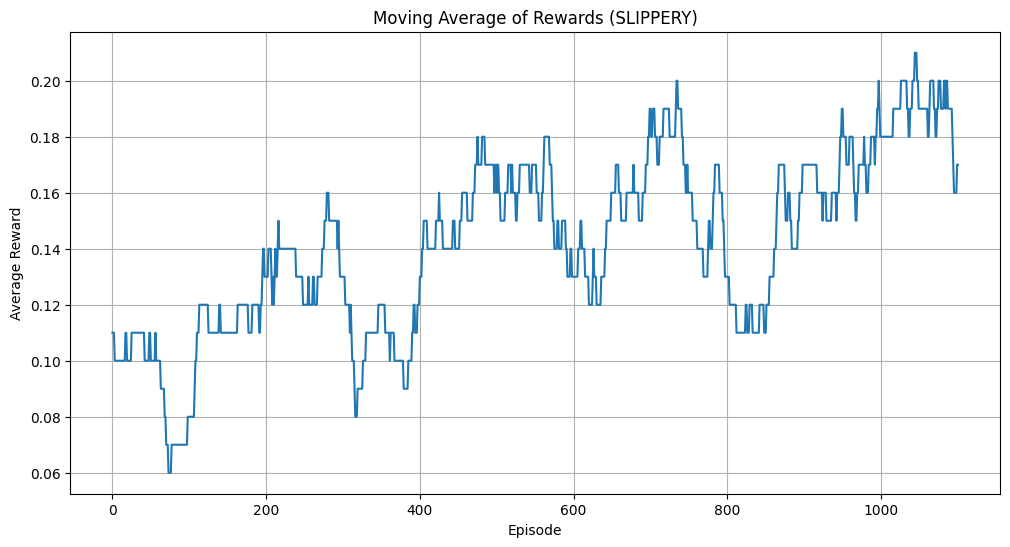

In [ ]:
window_size = 100
moving_avg_rewards_slippery = np.convolve(rewards_slippery, np.ones(window_size)/window_size, mode='valid')

plt.figure(figsize=(12, 6))
plt.plot(moving_avg_rewards_slippery)
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("Moving Average of Rewards (SLIPPERY)")
plt.grid(True)
plt.show()

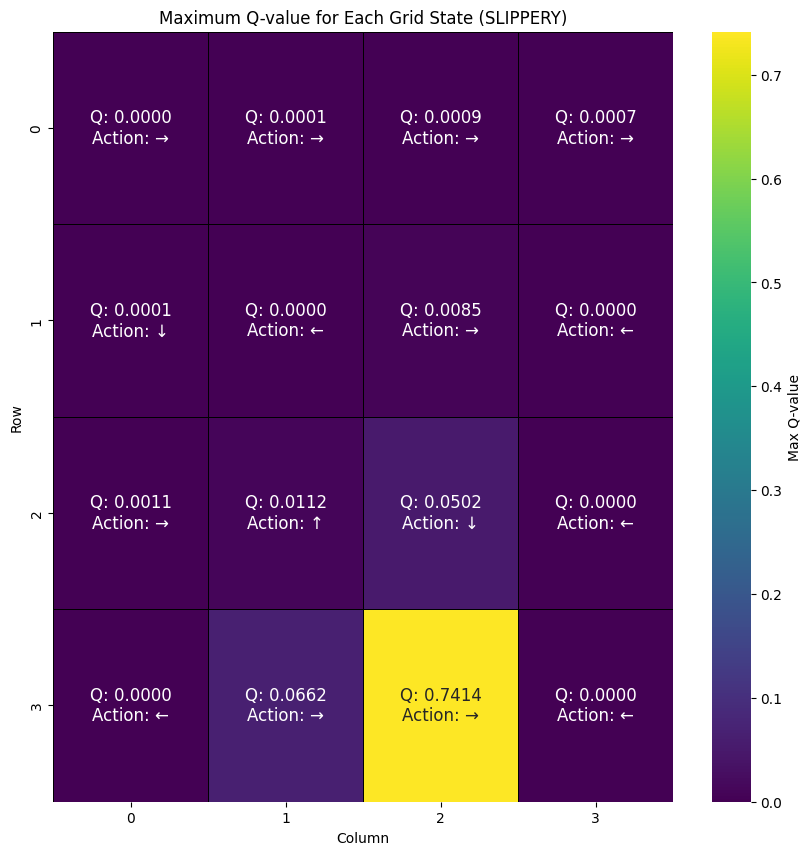

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
max_q_values_slippery = np.max(qtable_slippery, axis=1)
optimal_actions_slippery = np.argmax(qtable_slippery, axis=1)

#A map to showcase the action
action_symbols = {0: '←', 1: '↓', 2: '→', 3: '↑'}
optimal_actions_symbols_slippery = np.array([action_symbols[a] for a in optimal_actions_slippery])

annotations_slippery = []
for i in range(len(max_q_values_slippery)):
    annotations_slippery.append(f"Q: {max_q_values_slippery[i]:.4f}\nAction: {optimal_actions_symbols_slippery[i]}")

max_q_values_grid_slippery = max_q_values_slippery.reshape(4, 4)
annotations_grid_slippery = np.array(annotations_slippery).reshape(4, 4)

plt.figure(figsize=(10, 10))
sns.heatmap(max_q_values_grid_slippery, annot=annotations_grid_slippery, cmap="viridis", fmt="",
            linewidths=.5, linecolor='black',
            cbar_kws={'label': 'Max Q-value'},
            cbar=True,
            annot_kws={"size": 12})
plt.title("Maximum Q-value for Each Grid State (SLIPPERY)")
plt.xlabel("Column")
plt.ylabel("Row")

plt.show()

##Optimizing the Parameters

As in the non slippery case, we set out to complete a grid search to find a useful combination of the parameters. We use the same grid. The parameters we find are different from those of the non-slippery case, and less aggressive. Perhaps, the augmented uncertainty coming from the ice effect means we need a "slower moving" model to fit better. The best average found is 64%, against the 90% found in the non-slippery case, showing how difficult such a problem can become with a still high 0.8 success_rate parameter.

In [ ]:
alfa_values = [0.01, 0.1, 0.3, 0.5, 0.7, 0.9]
gamma_values = [0.1, 0.3, 0.5, 0.7, 0.9]
epsilon_0_values = [0.1, 0.3, 0.5, 0.7, 0.9]
decay_rate_values = [0.0001, 0.0005, 0.001]

In [ ]:
import itertools #Permette di scrivere semplicemente il loop

best_reward_slippery = -np.inf
best_params_slippery = {}

#Fixed parameters
total_episodes_grid = 1200
max_steps_grid = 100
min_epsilon_grid = 0.01
window_size_grid = 100

env_grid = gym.make("FrozenLake-v1", is_slippery=True, success_rate=0.8)
state_size_grid = env_grid.observation_space.n
action_size_grid = env_grid.action_space.n

#Iteration through all combinations
for alfa_val, gamma_val, epsilon_0_val, decay_rate_val in itertools.product(alfa_values, gamma_values, epsilon_0_values, decay_rate_values):
    print(f"\nTraining with: alfa={alfa_val}, gamma={gamma_val}, epsilon_0={epsilon_0_val}, decay_rate={decay_rate_val}")

    #Re-initialize Q-table for the current combination
    current_qtable = np.zeros((state_size_grid, action_size_grid))

    epsilon_current = epsilon_0_val
    epsilon_0_current = epsilon_0_val
    decay_rate_current = decay_rate_val
    gamma_current = gamma_val
    alfa_current = alfa_val

    current_rewards = []

    for episode in range(total_episodes_grid):
        state, _ = env_grid.reset()
        done = False
        total_episode_reward = 0

        for step in range(max_steps_grid):
            #epsilon-greedy selection
            if np.random.rand() > epsilon_current:
                action = np.argmax(current_qtable[state,:])
            else:
                action = env_grid.action_space.sample()

            new_state, reward, terminated, truncated, _ = env_grid.step(action)
            done = terminated or truncated

            #Update Rule
            current_qtable[state, action] = current_qtable[state, action] + alfa_current* \
                                            (reward + gamma_current*np.max(current_qtable[new_state,:])*(1 - done) - current_qtable[state, action])

            total_episode_reward += reward
            state = new_state

            if done:
                break

        epsilon_current = min_epsilon_grid + (epsilon_0_current - min_epsilon_grid)*np.exp(-decay_rate_current*episode)
        current_rewards.append(total_episode_reward)

    #Average reward over the last window size episodes
    if len(current_rewards) >= window_size_grid:
        avg_reward = np.mean(current_rewards[-window_size_grid:])

    print(f"  Average reward over last {window_size_grid} episodes: {avg_reward:.4f}")

    #Save the best results
    if avg_reward > best_reward_slippery:
        best_reward_slippery = avg_reward
        best_params_slippery = {
            "alfa": alfa_val,
            "gamma": gamma_val,
            "epsilon_0": epsilon_0_val,
            "decay_rate": decay_rate_val
        }
        print(f"  New best reward found: {best_reward:.4f} with params: {best_params}")

env_grid.close()
print(f"Best average reward: {best_reward_slippery:.4f}")
print(f"Best hyperparameters: {best_params_slippery}")


Training with: alfa=0.01, gamma=0.1, epsilon_0=0.1, decay_rate=0.0001
  Average reward over last 100 episodes: 0.0000
  New best reward found: 0.9300 with params: {'alfa': 0.5, 'gamma': 0.5, 'epsilon_0': 0.3, 'decay_rate': 0.001}

Training with: alfa=0.01, gamma=0.1, epsilon_0=0.1, decay_rate=0.0005
  Average reward over last 100 episodes: 0.0000

Training with: alfa=0.01, gamma=0.1, epsilon_0=0.1, decay_rate=0.001
  Average reward over last 100 episodes: 0.0000

Training with: alfa=0.01, gamma=0.1, epsilon_0=0.3, decay_rate=0.0001
  Average reward over last 100 episodes: 0.0000

Training with: alfa=0.01, gamma=0.1, epsilon_0=0.3, decay_rate=0.0005
  Average reward over last 100 episodes: 0.4500
  New best reward found: 0.9300 with params: {'alfa': 0.5, 'gamma': 0.5, 'epsilon_0': 0.3, 'decay_rate': 0.001}

Training with: alfa=0.01, gamma=0.1, epsilon_0=0.3, decay_rate=0.001
  Average reward over last 100 episodes: 0.0000

Training with: alfa=0.01, gamma=0.1, epsilon_0=0.5, decay_rate=

In [ ]:
print(f"Best hyperparameters found: {best_params_slippery}")
print(f"Highest average reward: {best_reward_slippery:.4f}")

Best hyperparameters found: {'alfa': 0.01, 'gamma': 0.1, 'epsilon_0': 0.5, 'decay_rate': 0.001}
Highest average reward: 0.6400


# Visualization

You are provided with some functions which will help you visualize the results as a video.
Feel free to write your own code for visualization if you prefer

In [ ]:
# For visualization
from gym.wrappers.monitoring import video_recorder
from IPython.display import HTML
from IPython import display
import glob
import base64, io, os

os.environ['SDL_VIDEODRIVER']='dummy'

In [ ]:
import gymnasium as gym

os.makedirs("video", exist_ok=True)

def show_video(env_name):
    # Function to show a video in the notebook. Do not modify.
    mp4list = glob.glob('video/*.mp4')
    if len(mp4list) > 0:
        mp4 = 'video/{}.mp4'.format(env_name)
        video = io.open(mp4, 'r+b').read()
        encoded = base64.b64encode(video)
        display.display(HTML(data='''<video alt="test" autoplay
                loop controls style="height: 400px;">
                <source src="data:video/mp4;base64,{0}" type="video/mp4" />
             </video>'''.format(encoded.decode('ascii'))))
    else:
        print("Could not find video")

def show_video_of_model(env_name, q_table, max_steps=100):
    # Create a new environment with render_mode for video recording
    local_env = gym.make(env_name, render_mode='rgb_array', is_slippery=False)
    vid = video_recorder.VideoRecorder(local_env, path="video/{}.mp4".format(env_name))
    state, _ = local_env.reset() # Fix: unpack the tuple returned by reset()
    done = False
    for t in range(max_steps):
        vid.capture_frame()
        action = np.argmax(q_table[state,:]) # Use q_table passed as argument
        next_state, reward, terminated, truncated, info = local_env.step(action)
        done = terminated or truncated
        print(f"state: {state}, action: {action}",next_state, reward, done)
        state = next_state
        if done:
            break
    vid.close()
    local_env.close()

In [ ]:
show_video_of_model("FrozenLake-v1", qtable_slippery)

/usr/local/lib/python3.12/dist-packages/gym/wrappers/monitoring/video_recorder.py:101: DeprecationWarning: WARN: <class 'gym.wrappers.monitoring.video_recorder.VideoRecorder'> is marked as deprecated and will be removed in the future.
  logger.deprecation(


state: 0, action: 1 4 0 False
state: 4, action: 1 8 0 False
state: 8, action: 2 9 0 False
state: 9, action: 1 13 0 False
state: 13, action: 2 14 0 False
state: 14, action: 2 15 1 True


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
show_video("FrozenLake-v1")